# Exploratory Data Analysis: Elliptic Bitcoin Dataset

This notebook explores the Elliptic Bitcoin dataset, a real-world graph of 
203,769 Bitcoin transactions labeled as licit, illicit, or unknown.

The goal is to understand the graph structure, class imbalance, and how 
fraud patterns evolve over time, which motivates the use of temporal GNNs.

In [ ]:
import torch
import torch_geometric
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.datasets import EllipticBitcoinDataset
import pandas as pd
import networkx as nx



dataset = EllipticBitcoinDataset(root='../data/elliptic')
data = dataset[0]

# Basic graph statistics
print("=== Dataset Overview ===")
print(f"Nodes: {data.num_nodes:,}")
print(f"Edges: {data.num_edges:,}")
print(f"Node features: {data.num_node_features}")
print(f"Directed: {data.is_directed()}")

Processing...
Done!


=== Dataset Overview ===
Nodes: 203,769
Edges: 234,355
Node features: 165
Directed: True


## 1. Dataset Overview & Class Distribution

Only 2.2% of labeled nodes are illicit, creating severe class imbalance. 
This means accuracy is a misleading metric, a model predicting everything 
as licit would achieve 97.8% accuracy while catching zero fraud.


=== Label Distribution ===
Licit: 42,019 (20.6%)
Illicit: 4,545 (2.2%)
Unknown: 157,205 (77.1%)


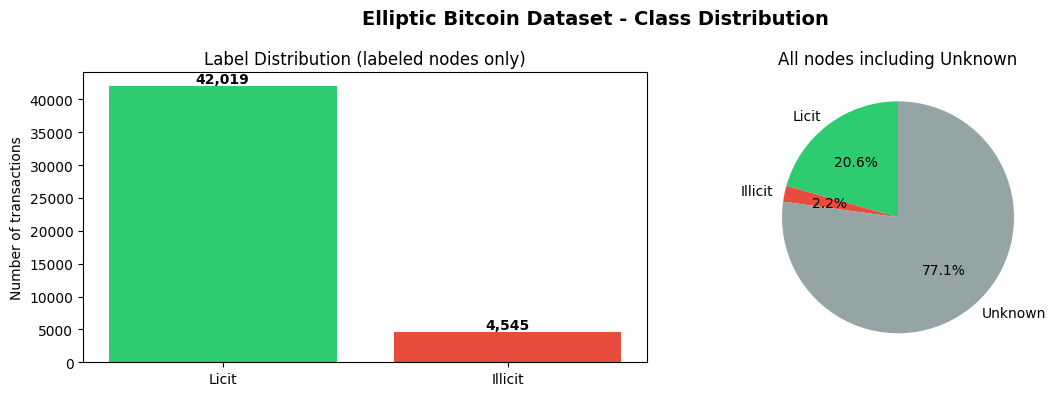

Plot saved


In [5]:
# Label distribution
labels = data.y.numpy()
unique, counts = np.unique(labels, return_counts=True)
label_names = {0: 'Licit', 1: 'Illicit', 2: 'Unknown'}

print("\n=== Label Distribution ===")
for val, count in zip(unique, counts):
    pct = count / len(labels) * 100
    print(f"{label_names[val]}: {count:,} ({pct:.1f}%)")

# Visualize label distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
labels_known = {
    'Licit': np.sum(labels == 0),
    'Illicit': np.sum(labels == 1)
}
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(labels_known.keys(), labels_known.values(), color=colors)
axes[0].set_title('Label Distribution (labeled nodes only)')
axes[0].set_ylabel('Number of transactions')

for i, (k, v) in enumerate(labels_known.items()):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    [np.sum(labels == 0), np.sum(labels == 1), np.sum(labels == 2)],
    labels=['Licit', 'Illicit', 'Unknown'],
    colors=['#2ecc71', '#e74c3c', '#95a5a6'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('All nodes including Unknown')

plt.suptitle('Elliptic Bitcoin Dataset - Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved")

## 3. Temporal Analysis

The dataset spans 49 timesteps (~2 weeks each). Fraud is not static:
patterns emerge and disappear over time, which is why static models 
generalize poorly to new fraud methods.

In [6]:
# Fix: load raw data to get timesteps correctly
import pandas as pd

feat_df = pd.read_csv('../data/elliptic/raw/elliptic_txs_features.csv', header=None)
class_df = pd.read_csv('../data/elliptic/raw/elliptic_txs_classes.csv')

# Column 1 is the timestep (column 0 is node id)
feat_df.columns = ['txId'] + [f'f{i}' for i in range(1, feat_df.shape[1])]
feat_df['timestep'] = feat_df['f1'].astype(int)

# Merge with labels
class_df.columns = ['txId', 'label']
df = feat_df[['txId', 'timestep']].merge(class_df, on='txId')

print(df['timestep'].value_counts().sort_index().head(10))
print(f"\nTimesteps range: {df['timestep'].min()} - {df['timestep'].max()}")
print(f"Label values: {df['label'].unique()}")

timestep
1     7880
2     4544
3     6621
4     5693
5     6803
6     4328
7     6048
8     4457
9     4996
10    6727
Name: count, dtype: int64

Timesteps range: 1 - 49
Label values: ['unknown' '2' '1']


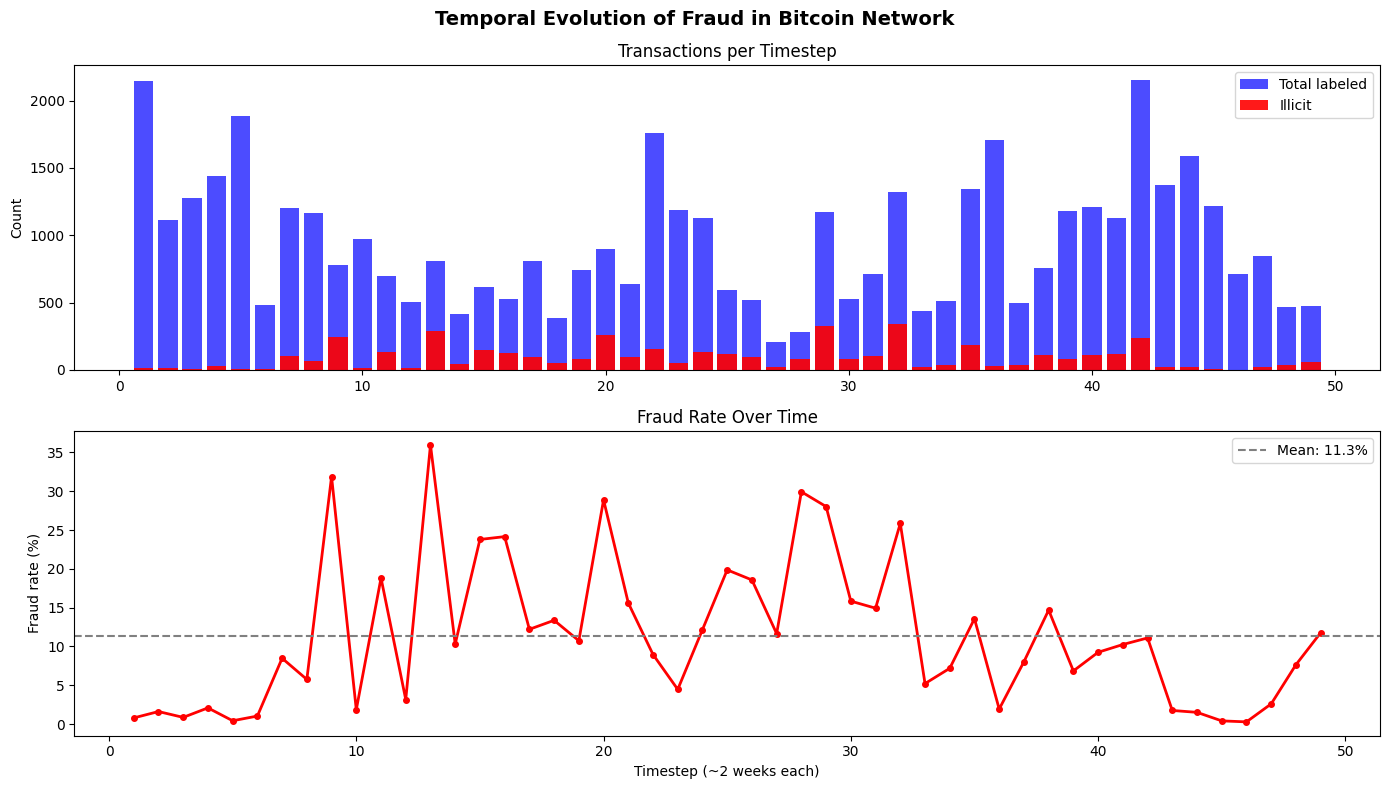

In [8]:
# Temporal analysis with correct data
df_labeled = df[df['label'] != 'unknown'].copy()
df_labeled['is_illicit'] = (df_labeled['label'] == '1').astype(int)

fraud_by_time = df_labeled.groupby('timestep').agg(
    total=('is_illicit', 'count'),
    illicit=('is_illicit', 'sum')
).reset_index()

fraud_by_time['fraud_rate'] = fraud_by_time['illicit'] / fraud_by_time['total'] * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Transactions per timestep
axes[0].bar(
    fraud_by_time['timestep'],
    fraud_by_time['total'],
    color='blue',
    alpha=0.7,
    label='Total labeled'
)
axes[0].bar(
    fraud_by_time['timestep'],
    fraud_by_time['illicit'],
    color='red',
    alpha=0.9,
    label='Illicit'
)
axes[0].set_title('Transactions per Timestep')
axes[0].set_ylabel('Count')
axes[0].legend()

# Fraud rate over time
mean_fraud_rate = fraud_by_time['fraud_rate'].mean()

axes[1].plot(
    fraud_by_time['timestep'],
    fraud_by_time['fraud_rate'],
    color='red',
    linewidth=2,
    marker='o',
    markersize=4
)
axes[1].axhline(
    y=mean_fraud_rate,
    color='gray',
    linestyle='--',
    label=f'Mean: {mean_fraud_rate:.1f}%'
)
axes[1].set_title('Fraud Rate Over Time')
axes[1].set_xlabel('Timestep (~2 weeks each)')
axes[1].set_ylabel('Fraud rate (%)')
axes[1].legend()

plt.suptitle(
    'Temporal Evolution of Fraud in Bitcoin Network',
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('../data/temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Graph Structure Analysis

The degree distribution reveals a power-law pattern typical of real-world networks:
most nodes have very few connections, while a small number act as hubs.

Notably, illicit nodes have a slightly lower average degree (1.15) than licit ones (1.19),
suggesting fraudulent transactions tend to avoid highly connected nodes, 
a behavioral pattern that GNNs can exploit through neighborhood aggregation.

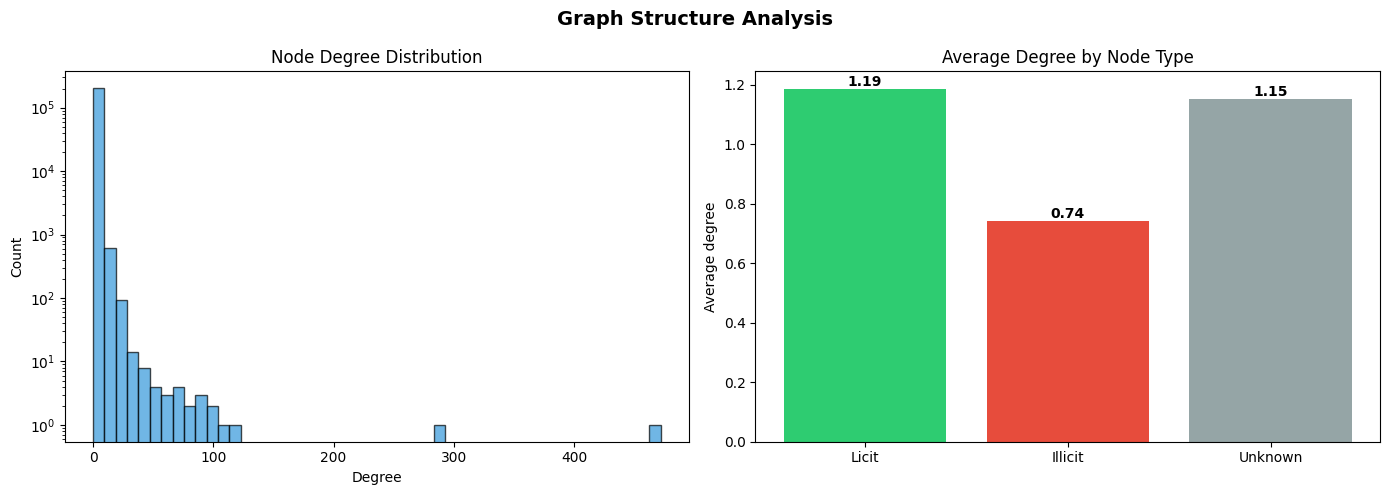

Average degree: 1.15
Max degree: 472
Nodes with degree 0: 37,424


In [9]:
# Degree distribution
edge_index = data.edge_index.numpy()
degrees = np.bincount(edge_index[0], minlength=data.num_nodes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Degree distribution histogram
axes[0].hist(degrees, bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title('Node Degree Distribution')
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Count')
axes[0].set_yscale('log')

# Degree by label
df_degree = pd.DataFrame({
    'degree': degrees,
    'label': data.y.numpy()
})

label_names = {0: 'Licit', 1: 'Illicit', 2: 'Unknown'}
df_degree['label_name'] = df_degree['label'].map(label_names)

mean_degrees = df_degree.groupby('label_name')['degree'].mean()
mean_degrees = mean_degrees.reindex(['Licit', 'Illicit', 'Unknown'])

colors = ['#2ecc71', '#e74c3c', '#95a5a6']

axes[1].bar(mean_degrees.index, mean_degrees.values, color=colors)
axes[1].set_title('Average Degree by Node Type')
axes[1].set_ylabel('Average degree')

for i, (idx, val) in enumerate(mean_degrees.items()):
    axes[1].text(i, val + 0.01, f'{val:.2f}', ha='center', fontweight='bold')

plt.suptitle('Graph Structure Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/graph_structure.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average degree: {degrees.mean():.2f}")
print(f"Max degree: {degrees.max()}")
print(f"Nodes with degree 0: {(degrees == 0).sum():,}")

 ## 4. Graph Visualization

A subgraph sample from timestep 1, colored by node type.
Red = illicit, green = licit, gray = unknown.

/tmp/ipykernel_13854/4140198211.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


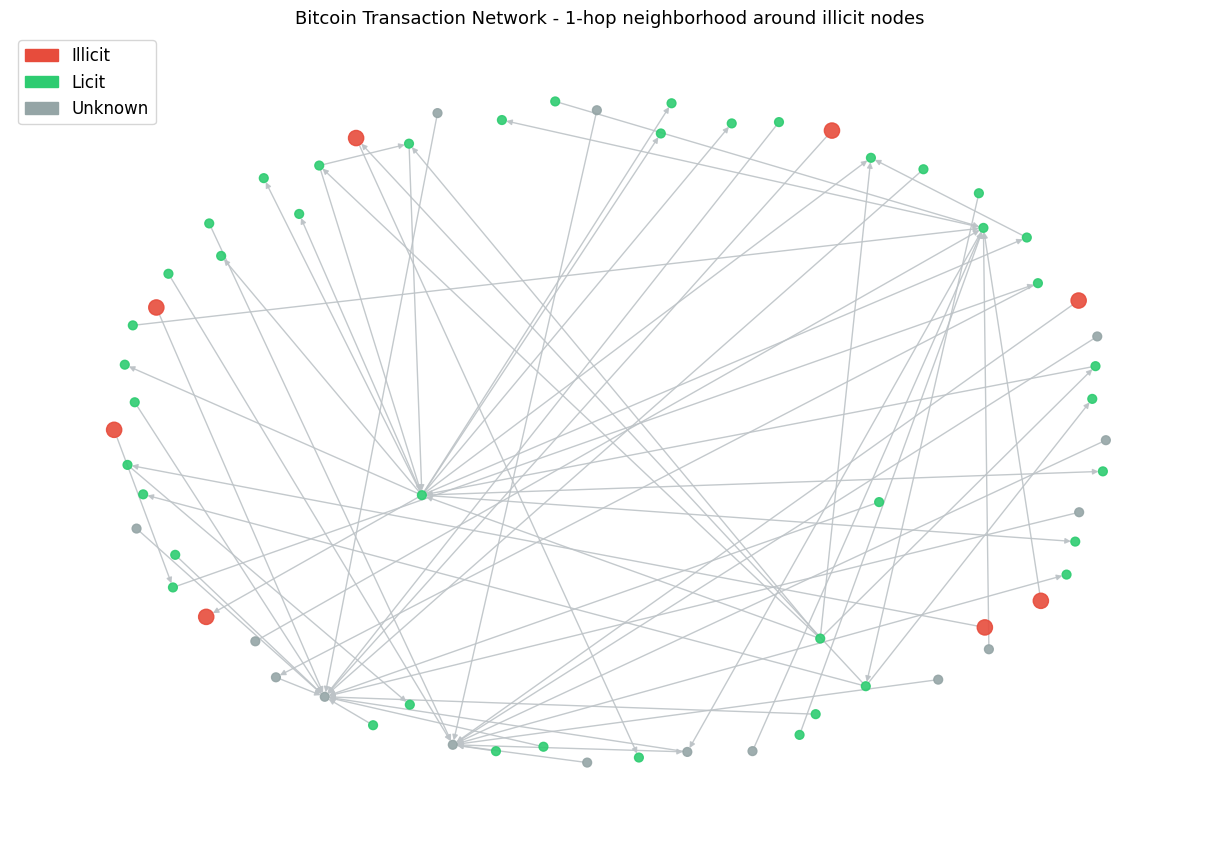

Nodes: 65 | Edges: 67


In [43]:
edge_index = data.edge_index.cpu().numpy()
labels = data.y.cpu().numpy()

# Find illicit nodes in timestep 5
t_mask = (timesteps == 5).numpy()
illicit_nodes = np.where(t_mask & (labels == 1))[0][:20]

# 2-hop neighborhood
nodes_to_include = set(illicit_nodes.tolist())
for _ in range(2):
    new_nodes = set()
    for i in range(edge_index.shape[1]):
        if edge_index[0][i] in nodes_to_include:
            new_nodes.add(edge_index[1][i])
        if edge_index[1][i] in nodes_to_include:
            new_nodes.add(edge_index[0][i])
    nodes_to_include.update(new_nodes)

nodes_to_include = list(nodes_to_include)[:120]

# Build graph
G = nx.DiGraph()
G.add_nodes_from(nodes_to_include)
nodes_set = set(nodes_to_include)
for i in range(edge_index.shape[1]):
    if edge_index[0][i] in nodes_set and edge_index[1][i] in nodes_set:
        G.add_edge(edge_index[0][i], edge_index[1][i])

color_map = {0: '#95a5a6', 1: '#e74c3c', 2: '#2ecc71'}
node_colors = [color_map[labels[n]] for n in G.nodes()]
node_sizes = [120 if labels[n] == 1 else 40 for n in G.nodes()]

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42, k=3, iterations=100)
nx.draw(G, pos,
        node_color=node_colors,
        node_size=node_sizes,
        edge_color='#bdc3c7',
        arrows=True,
        arrowsize=8,
        alpha=0.9)

legend = [Patch(color='#e74c3c', label='Illicit'),
          Patch(color='#2ecc71', label='Licit'),
          Patch(color='#95a5a6', label='Unknown')]
plt.legend(handles=legend, loc='upper left', fontsize=12)
plt.title('Bitcoin Transaction Network - 1-hop neighborhood around illicit nodes', fontsize=13)
plt.tight_layout()
plt.savefig('../assets/graph_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")

In [12]:
from matplotlib.patches import Patch

Illicit nodes found in timestep 5: 8


C:\Users\siria\AppData\Local\Temp\ipykernel_18336\2795376574.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


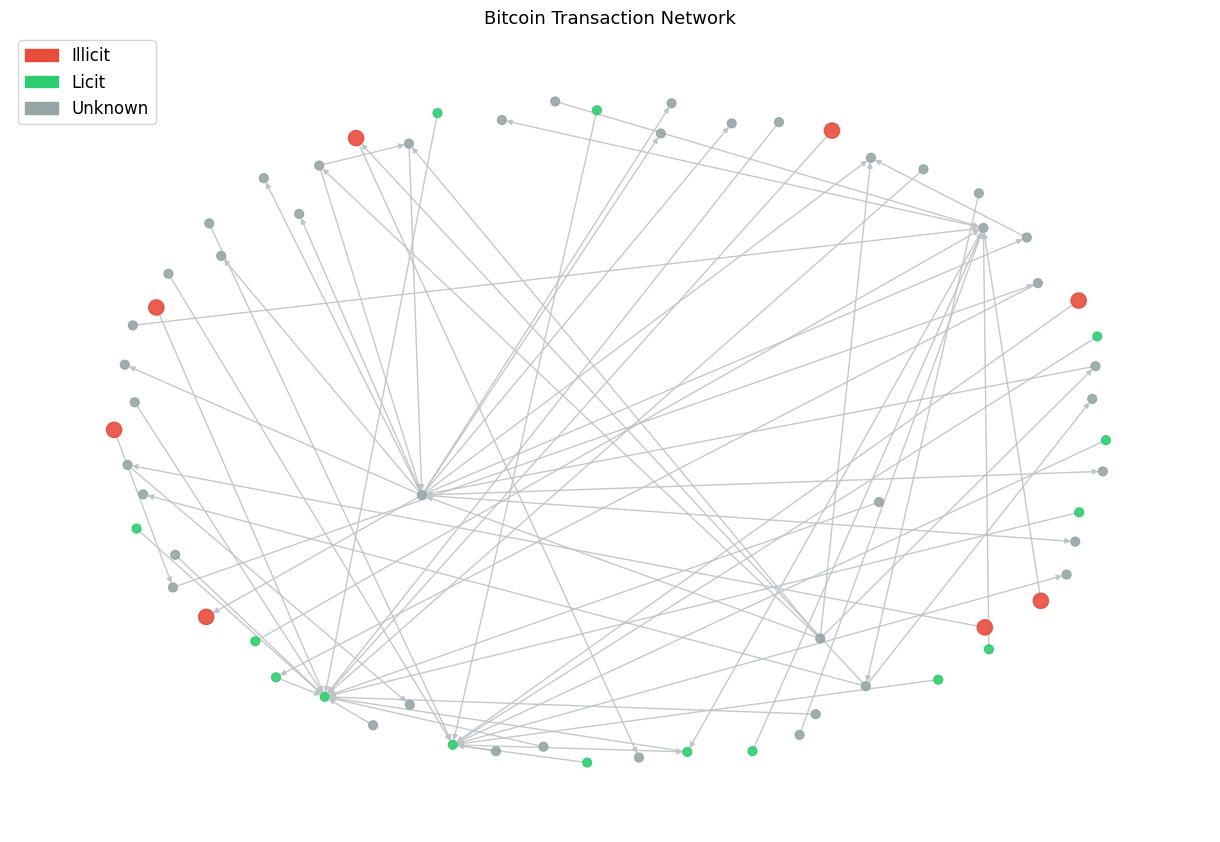

Nodes: 65 | Edges: 67


In [14]:
# Load timesteps from raw Elliptic data
feat_df = pd.read_csv('../data/elliptic/raw/elliptic_txs_features.csv', header=None)

# Column 0 = txId, Column 1 = timestep
timesteps = feat_df.iloc[:, 1].astype(int).values

# Graph data
edge_index = data.edge_index.cpu().numpy()
labels = data.y.cpu().numpy()

# Find illicit nodes in timestep 5
t_mask = (timesteps == 5)
illicit_nodes = np.where(t_mask & (labels == 1))[0][:20]

print(f"Illicit nodes found in timestep 5: {len(illicit_nodes)}")

# 2-hop neighborhood
nodes_to_include = set(illicit_nodes.tolist())

for _ in range(2):
    new_nodes = set()

    for i in range(edge_index.shape[1]):
        src, dst = edge_index[:, i]

        if src in nodes_to_include:
            new_nodes.add(dst)
        if dst in nodes_to_include:
            new_nodes.add(src)

    nodes_to_include.update(new_nodes)

nodes_to_include = list(nodes_to_include)[:120]

# Build graph
G = nx.DiGraph()
G.add_nodes_from(nodes_to_include)

nodes_set = set(nodes_to_include)

for i in range(edge_index.shape[1]):
    src, dst = edge_index[:, i]

    if src in nodes_set and dst in nodes_set:
        G.add_edge(src, dst)

# Correct label colors
# 0 = Licit, 1 = Illicit, 2 = Unknown
color_map = {
    0: '#2ecc71',
    1: '#e74c3c',
    2: '#95a5a6'
}

node_colors = [color_map[labels[n]] for n in G.nodes()]
node_sizes = [120 if labels[n] == 1 else 40 for n in G.nodes()]

# Draw graph
plt.figure(figsize=(12, 8))

pos = nx.spring_layout(
    G,
    seed=42,
    k=3,
    iterations=100
)

nx.draw(
    G,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    edge_color='#bdc3c7',
    arrows=True,
    arrowsize=8,
    alpha=0.9
)

legend = [
    Patch(color='#e74c3c', label='Illicit'),
    Patch(color='#2ecc71', label='Licit'),
    Patch(color='#95a5a6', label='Unknown')
]

plt.legend(handles=legend, loc='upper left', fontsize=12)

plt.title(
    'Bitcoin Transaction Network',
    fontsize=13
)

plt.tight_layout()
plt.savefig(
    '../assets/graph_visualization.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(f"Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")